# Part 5 — Decoding: Temperature, Top-k, and Top-p

**Guiding question:** Why does the same model, given the same question, produce a different answer each time?

**Purpose:** see the step that happens *after* the model has finished computing. A model does not output text. It outputs a score for every token in its vocabulary. **Decoding** is the rule that turns those scores into one chosen token, and it is a setting you control.

**Runtime:** about 20 minutes. **Roadmap:** scores → softmax → temperature → sampling → top-k → top-p → generate real sentences → what to set for health work.

**Safety and scope:** the generator in this notebook is a deliberately tiny word-frequency model built from fictional clinic text. It is **not** a language model and its sentences carry no meaning or clinical validity. It is here so the decoding arithmetic is fully visible. Run cells from top to bottom.

## 0. Setup

**Logits** are the raw scores a model assigns to each candidate next token. **Softmax** converts them into probabilities that sum to one — the same function used inside attention in Part 4. **Decoding** selects one token from that distribution.

`RANDOM_STATE` fixes the sampler so the notebook is reproducible. In a hosted API you usually cannot fix it.

In [1]:
import re, sys
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")
print({"python": sys.version.split()[0], "numpy": np.__version__})

{'python': '3.13.5', 'numpy': '2.2.6'}


## 1. What the model actually hands over

Suppose a model has processed the prompt *"An urgent laboratory result is communicated by the ..."* and must choose the next word.

It produces one score per candidate. Higher means the model rated that continuation as more likely. These are the raw numbers before any decision is made.

**Look for:** the scores are not probabilities. They are unbounded and do not sum to anything in particular.

In [2]:
CANDIDATES = ["clinician", "nurse", "physician", "portal", "team", "system", "email", "fax"]
LOGITS = np.array([4.2, 3.1, 2.8, 1.4, 1.1, 0.3, -0.6, -1.8])

logit_table = pd.DataFrame({"candidate next token": CANDIDATES, "logit (raw score)": LOGITS})
display(logit_table)
print(f"sum of logits = {LOGITS.sum():.1f}  (a sum with no useful meaning)")

,candidate next token,logit (raw score)
0,clinician,4.2
1,nurse,3.1
2,physician,2.8
3,portal,1.4
4,team,1.1
5,system,0.3
6,email,-0.6
7,fax,-1.8


sum of logits = 10.5  (a sum with no useful meaning)


### What do we see?

Eight candidates with eight scores. `clinician` scored highest, `fax` lowest. Nothing has been chosen yet and no randomness has entered.

Every decoding setting in this notebook operates on this vector. The model's own computation is already finished and does not change.

## 2. Softmax turns scores into probabilities

Softmax exponentiates each score and divides by the total, so the results are non-negative and sum to one.

`probability_i = exp(logit_i) / sum_j exp(logit_j)`

**Look for:** the probabilities sum to 1.000, and the ordering is unchanged from the logits.

In [3]:
def softmax(logits, temperature=1.0):
    """Convert logits to probabilities, optionally sharpened or flattened by temperature."""
    scaled = np.asarray(logits, dtype=float) / temperature
    shifted = scaled - scaled.max()          # subtract the max for numerical stability
    exponentiated = np.exp(shifted)
    return exponentiated / exponentiated.sum()


base_probabilities = softmax(LOGITS)
display(pd.DataFrame({"token": CANDIDATES,
                      "logit": LOGITS,
                      "probability": base_probabilities.round(4)}))
print(f"sum of probabilities = {base_probabilities.sum():.3f}")

,token,logit,probability
0,clinician,4.2,0.5827
1,nurse,3.1,0.1939
2,physician,2.8,0.1437
3,portal,1.4,0.0354
4,team,1.1,0.0262
5,system,0.3,0.0118
6,email,-0.6,0.0048
7,fax,-1.8,0.0014


sum of probabilities = 1.000


### What do we see?

`clinician` holds about 63% of the probability mass. `fax` holds well under 1%. Softmax preserved the ranking and made the numbers comparable.

Note that `fax` is not impossible. It has a small but non-zero probability. Whether that matters depends entirely on the decoding rule applied next.

## 3. Temperature reshapes the distribution

Temperature divides the logits before softmax.

- **T below 1** makes large scores relatively larger. The distribution becomes **sharper** and output more predictable.
- **T = 1** leaves the model's own distribution unchanged.
- **T above 1** flattens the distribution and makes unlikely tokens more reachable.

**Look for:** what happens to the `fax` column as temperature rises, and to `clinician` as it falls.

,T=0.2,T=0.5,T=1.0,T=1.5,T=2.0
clinician,0.9950,0.8490,0.5827,0.4370,0.3552
nurse,0.0041,0.0941,0.1939,0.2099,0.2049
physician,0.0009,0.0516,0.1437,0.1719,0.1764
portal,0.0000,0.0031,0.0354,0.0676,0.0876
team,0.0000,0.0017,0.0262,0.0553,0.0754
system,0.0000,0.0003,0.0118,0.0325,0.0505
email,0.0000,0.0001,0.0048,0.0178,0.0322
fax,0.0000,0.0000,0.0014,0.0080,0.0177


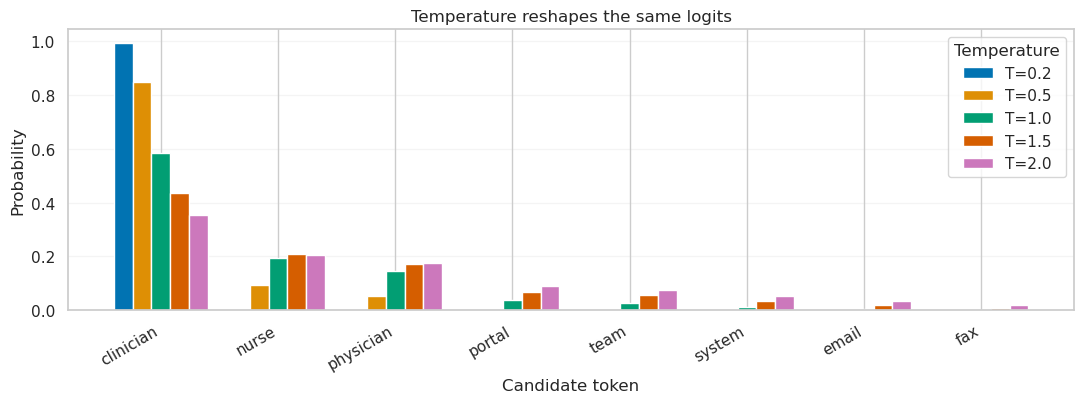

In [4]:
TEMPERATURES = [0.2, 0.5, 1.0, 1.5, 2.0]

temperature_table = pd.DataFrame(
    {f"T={t}": softmax(LOGITS, temperature=t) for t in TEMPERATURES},
    index=CANDIDATES).round(4)
display(temperature_table)

fig, ax = plt.subplots(figsize=(11, 4.2))
width = 0.16
positions = np.arange(len(CANDIDATES))
for offset, t in enumerate(TEMPERATURES):
    ax.bar(positions + (offset - 2) * width, softmax(LOGITS, t), width, label=f"T={t}")
ax.set(title="Temperature reshapes the same logits", xlabel="Candidate token", ylabel="Probability")
ax.set_xticks(positions); ax.set_xticklabels(CANDIDATES, rotation=30, ha="right")
ax.legend(title="Temperature"); ax.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.show()

### What do we see?

At `T=0.2` almost all the mass sits on `clinician`: the model will say the same thing nearly every time. At `T=2.0` the distribution has flattened enough that `email` and `fax` become realistic choices.

The model's scores never changed. Only the rule for reading them changed.

**A common misconception:** temperature is not a confidence or accuracy setting. Lowering it does not make the model more correct. It makes the model more **repeatable** — including repeatably wrong.

## 4. Greedy decoding versus sampling

Two ways to use the distribution:

- **Greedy** (equivalent to temperature 0): always take the highest-probability token. Deterministic.
- **Sampling:** draw a token at random in proportion to the probabilities. Different every run.

Draw 2,000 samples at two temperatures and count what actually comes out.

**Look for:** how often a low-probability token is selected at each temperature.

In [5]:
def sample_counts(logits, temperature, n_draws=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    probabilities = softmax(logits, temperature)
    draws = rng.choice(len(logits), size=n_draws, p=probabilities)
    return Counter(draws)


rows = []
for temperature in [0.2, 1.0, 2.0]:
    counts = sample_counts(LOGITS, temperature)
    rows.append({"setting": f"sampling, T={temperature}",
                 **{CANDIDATES[i]: counts.get(i, 0) for i in range(len(CANDIDATES))}})
rows.insert(0, {"setting": "greedy (T=0)",
                **{token: (2000 if token == CANDIDATES[int(np.argmax(LOGITS))] else 0)
                   for token in CANDIDATES}})

display(pd.DataFrame(rows).set_index("setting"))
print("Counts out of 2,000 draws each.")

,clinician,nurse,physician,portal,team,system,email,fax
setting,,,,,,,,
greedy (T=0),2000,0,0,0,0,0,0,0
"sampling, T=0.2",1990,8,2,0,0,0,0,0
"sampling, T=1.0",1162,368,299,78,51,28,8,6
"sampling, T=2.0",707,410,324,189,161,105,63,41


Counts out of 2,000 draws each.


### What do we see?

Greedy decoding returns `clinician` 2,000 times out of 2,000. It never explores anything else.

At `T=1.0` the sampler follows the model's own distribution: `clinician` most of the time, but `nurse` and `physician` regularly. At `T=2.0`, `fax` — a token the model scored *lowest* — gets selected a meaningful number of times.

This is the mechanism behind "the model gave me a different answer when I asked again." It is not instability or a bug. It is sampling, working as configured.

## 5. Top-k: keep only the k highest-scoring tokens

Top-k truncation discards everything outside the k best candidates, then renormalises the survivors so they sum to one.

**Look for:** the discarded tokens receive probability exactly 0, not a small number.

In [6]:
def apply_top_k(probabilities, k):
    """Keep the k highest probabilities, zero the rest, and renormalise."""
    if k >= len(probabilities):
        return probabilities.copy()
    kept_indices = np.argsort(probabilities)[-k:]
    truncated = np.zeros_like(probabilities)
    truncated[kept_indices] = probabilities[kept_indices]
    return truncated / truncated.sum()


top_k_table = pd.DataFrame(
    {"no truncation": base_probabilities,
     "top-k = 3": apply_top_k(base_probabilities, 3),
     "top-k = 1": apply_top_k(base_probabilities, 1)},
    index=CANDIDATES).round(4)
display(top_k_table)
print("top-k = 1 is identical to greedy decoding.")

,no truncation,top-k = 3,top-k = 1
clinician,0.5827,0.6331,1.0
nurse,0.1939,0.2107,0.0
physician,0.1437,0.1561,0.0
portal,0.0354,0.0000,0.0
team,0.0262,0.0000,0.0
system,0.0118,0.0000,0.0
email,0.0048,0.0000,0.0
fax,0.0014,0.0000,0.0


top-k = 1 is identical to greedy decoding.


### What do we see?

With `k=3` only `clinician`, `nurse`, and `physician` survive. `fax` cannot be produced at all, regardless of temperature, because its probability is now exactly zero.

With `k=1` the result is greedy decoding.

Top-k uses a **fixed count**. That is its weakness: three candidates may be too few when the model is genuinely uncertain across many options, and too many when it is nearly certain.

## 6. Top-p (nucleus): keep the smallest set reaching probability p

Top-p sorts tokens by probability and keeps adding them until their total reaches `p`. The number kept therefore **adapts** to how confident the model is.

**Look for:** the `tokens kept` column changes with the shape of the distribution, not with a fixed setting.

In [7]:
def apply_top_p(probabilities, p):
    """Keep the smallest set of top tokens whose cumulative probability reaches p."""
    order = np.argsort(probabilities)[::-1]
    cumulative = np.cumsum(probabilities[order])
    n_keep = int(np.searchsorted(cumulative, p) + 1)
    kept_indices = order[:n_keep]
    truncated = np.zeros_like(probabilities)
    truncated[kept_indices] = probabilities[kept_indices]
    return truncated / truncated.sum(), n_keep


rows = []
for label, probabilities in [("confident model (T=0.5)", softmax(LOGITS, 0.5)),
                             ("model's own (T=1.0)", softmax(LOGITS, 1.0)),
                             ("uncertain model (T=2.0)", softmax(LOGITS, 2.0))]:
    for p in [0.5, 0.9]:
        _, n_keep = apply_top_p(probabilities, p)
        rows.append({"distribution": label, "top-p": p, "tokens kept": n_keep})

display(pd.DataFrame(rows))

,distribution,top-p,tokens kept
0,confident model (T=0.5),0.5,1
1,confident model (T=0.5),0.9,2
2,model's own (T=1.0),0.5,1
3,model's own (T=1.0),0.9,3
4,uncertain model (T=2.0),0.5,2
5,uncertain model (T=2.0),0.9,6


### What do we see?

At `p=0.9` a confident distribution keeps only two or three tokens, while a flattened one keeps most of the vocabulary. Top-k would have kept exactly `k` in both cases.

That adaptivity is why top-p is the more common default. Note that temperature and top-p interact: they are applied in sequence, so changing one changes what the other does.

## 7. Generate actual sentences under different settings

The cell below builds a **bigram model**: for each word, it counts which words followed it in the fictional corpus. That is the entire model. It has no understanding of grammar or clinical meaning.

It is used here for one reason: every number is inspectable, so you can see decoding change the output without a black box in the way.

**Look for:** how the same starting word produces different continuations under different settings.

In [8]:
CORPUS = [
    "the nurse reviewed the laboratory result and contacted the patient",
    "the nurse reviewed the urgent result and telephoned the patient",
    "the clinician telephoned the patient about the urgent result",
    "the clinician documented the contact attempt in the record",
    "the laboratory posted the routine result to the portal",
    "the portal recorded the appointment and sent the reminder",
    "the scheduling desk confirmed the appointment in the portal",
    "the scheduling desk recorded the accommodation for the visit",
    "the privacy office reviewed the audit log for the record",
    "the audit log recorded the portal record view",
    "the ordering team answered the question about the result",
    "the patient requested proxy access through the portal",
]

followers = defaultdict(Counter)
for sentence in CORPUS:
    words = sentence.split()
    for current, nxt in zip(words, words[1:]):
        followers[current][nxt] += 1

def next_token_distribution(word):
    counts = followers[word]
    tokens = sorted(counts)
    frequencies = np.array([counts[t] for t in tokens], dtype=float)
    return tokens, np.log(frequencies)   # counts -> logit-like scores

tokens, scores = next_token_distribution("the")
display(pd.DataFrame({"token after 'the'": tokens,
                      "times seen": [followers["the"][t] for t in tokens],
                      "probability": softmax(scores).round(3)}).sort_values(
                          "times seen", ascending=False).head(8).reset_index(drop=True))

,token after 'the',times seen,probability
0,portal,5,0.147
1,patient,4,0.118
2,appointment,2,0.059
3,nurse,2,0.059
4,audit,2,0.059
5,clinician,2,0.059
6,laboratory,2,0.059
7,scheduling,2,0.059


### Generate with a chosen decoding rule

The generator below applies, in order: temperature, then top-k, then top-p, then samples. That is the same order used by production APIs.

**Look for:** greedy output repeating itself, and high-temperature output drifting into incoherence.

In [9]:
def generate(start_word, n_words=12, temperature=1.0, top_k=None, top_p=None, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    produced = [start_word]
    for _ in range(n_words):
        current = produced[-1]
        if not followers[current]:
            break
        tokens, scores = next_token_distribution(current)
        probabilities = softmax(scores, temperature)
        if top_k is not None:
            probabilities = apply_top_k(probabilities, top_k)
        if top_p is not None:
            probabilities, _ = apply_top_p(probabilities, top_p)
        if temperature <= 0.01:
            choice = int(np.argmax(probabilities))
        else:
            choice = int(rng.choice(len(tokens), p=probabilities))
        produced.append(tokens[choice])
    return " ".join(produced)


SETTINGS = [
    ("greedy (T->0)",            dict(temperature=0.01)),
    ("low temperature T=0.3",    dict(temperature=0.3)),
    ("default T=1.0",            dict(temperature=1.0)),
    ("high temperature T=2.0",   dict(temperature=2.0)),
    ("T=1.0 with top-k=2",       dict(temperature=1.0, top_k=2)),
    ("T=1.0 with top-p=0.6",     dict(temperature=1.0, top_p=0.6)),
]

display(pd.DataFrame([{"setting": label, "generated text": generate("the", **kwargs)}
                      for label, kwargs in SETTINGS]))

,setting,generated text
0,greedy (T->0),the portal record view
1,low temperature T=0.3,the portal record view
2,default T=1.0,the reminder
3,high temperature T=2.0,the result and telephoned the appointment in t...
4,T=1.0 with top-k=2,the portal record view
5,T=1.0 with top-p=0.6,the record view


### What do we see?

Greedy decoding follows the single highest-count path every time and stops as soon as it reaches a word nothing followed in the corpus. Low temperature does the same thing here. That is the character of greedy decoding: it commits to one route and never explores. With a larger model the same behaviour shows up as repetition loops.

At `T=2.0` the text runs much longer and wanders, because rare continuations became reachable.

`top-k=2` and `top-p=0.6` sit in between: still sampled, but the least plausible continuations were removed first.

Remember what this demonstrates and what it does not. It shows decoding changing output. It does not show a language model, and none of these sentences mean anything.

## 8. Run the same setting five times

The single most important practical property: with any temperature above 0, repeating the identical request gives different text.

**Look for:** the `distinct outputs` count for each setting.

In [10]:
rows = []
for label, kwargs in [("greedy (T->0)", dict(temperature=0.01)),
                      ("T=0.3", dict(temperature=0.3)),
                      ("T=1.0", dict(temperature=1.0))]:
    outputs = [generate("the", n_words=10, seed=seed, **kwargs) for seed in range(5)]
    rows.append({"setting": label,
                 "distinct outputs": len(set(outputs)),
                 "example run 1": outputs[0],
                 "example run 2": outputs[1]})

display(pd.DataFrame(rows))

,setting,distinct outputs,example run 1,example run 2
0,greedy (T->0),1,the portal record view,the portal record view
1,T=0.3,5,the portal record view,the portal recorded the scheduling desk confir...
2,T=1.0,5,the portal record view,the portal recorded the urgent result and tele...


### What do we see?

Greedy decoding gives one output five times out of five, because the seed never enters the calculation.

Both sampling settings give five different outputs from five identical requests. Note that `T=0.3` varied just as much as `T=1.0` here. Lowering temperature made the *common* continuations more likely, but as long as more than one option keeps non-zero probability, repeated runs can still differ. Low temperature reduces variation; only `temperature=0` removes it.

Now connect this to health work. If you ask a hosted model to summarise the same discharge note twice and get two different summaries, that is decoding — not the model changing its mind, and not evidence that either summary is right. Two identical outputs are not evidence of correctness either; greedy decoding is perfectly capable of returning the same wrong answer every time.

## 9. Choosing settings for health work

There is no universally correct setting. There is a defensible setting for a stated task.

| Task | Reasonable starting point | Reason |
|---|---|---|
| Extracting a value from a document | `temperature=0` (greedy) | You want the same answer every run and there is one correct answer. |
| Grounded question answering over retrieved policy (Part 6) | Low temperature, e.g. `0`–`0.3` | Wording should follow the evidence, not vary creatively. |
| Drafting patient-facing wording for a human to edit | Moderate, e.g. `0.7` with `top_p=0.9` | Some variation is useful when a person reviews every output. |
| Anything where two runs must match for audit | `temperature=0`, and record the model name and version | Reproducibility is a governance requirement, not a quality claim. |

Three cautions to carry forward:

1. `temperature=0` gives **repeatability, not accuracy**.
2. A provider can change model versions underneath you, so even `temperature=0` is not reproducible across time unless the version is pinned and recorded.
3. Decoding settings cannot fix missing evidence. That is what Part 6 addresses.

## 10. Learner checks

1. **Does raising temperature change what the model computed?** No. It changes only how the scores are read.
2. **Is `top_k=1` different from greedy decoding?** No, they are the same rule.
3. **Why does top-p keep a different number of tokens in different situations?** It keeps the smallest set reaching the cumulative threshold, so a confident distribution needs fewer tokens.
4. **You get two different summaries of the same note. What is the first thing to check?** The decoding settings, then whether the model version changed.
5. **Does `temperature=0` mean the answer is correct?** No. It means you will get the same answer again.
6. **Can decoding settings stop a model inventing a fact that is not in its input?** No. That requires supplying and checking evidence, which is Part 6.

## Summary, limitations, and completion checklist

**Result:** a model outputs a score for every candidate token. Temperature reshapes those scores, top-k and top-p remove candidates, and sampling makes the final choice. All of this happens after the model's computation and all of it is under your control.

- [x] Converted logits to probabilities with softmax.
- [x] Measured how temperature sharpens and flattens the same distribution.
- [x] Compared greedy decoding with sampling over 2,000 draws.
- [x] Applied top-k and top-p truncation and saw discarded tokens reach probability zero.
- [x] Generated text under six settings from one transparent model.
- [x] Confirmed that sampling makes repeated identical requests produce different outputs.

**Limits:** the generator here is a bigram word-count model, not a language model — it has no grammar, no context beyond one word, and no meaning. Real APIs also expose penalties, stop sequences, and seeds not covered here. Nothing in this notebook evaluates whether generated text is true.

**Try it yourself:** set `top_k=1` and vary `temperature` from 0.1 to 3.0. Explain why the output does not change.

Next: `Part-6_RAG_With_and_Without_Retrieval.ipynb`, which supplies evidence rather than adjusting how text is sampled.